# Notebook 05c — Diagnostic Run C: no NB 04 warm-start (MMHS150K T1 fine-tune)

**Question this run answers:** *Does the NB 04 warm-start on Cyberbullying Kaggle help or hurt MMHS150K T1 fine-tuning?*

**Context.** Two previous NB 05 attempts both plateaued at val AUC ≈ 0.74:
- **Run 1 (warm-start + pos_weight, 5 epochs):** test AUC 0.7398 · F1m 0.6885 · FPR 0.3071.
- **Run 2 (warm-start, no pos_weight, halted at epoch 1):** val AUC 0.7424 at epoch 1 — within 0.0003 of Run 1's epoch-1 AUC. Dropping `pos_weight` had **no effect on AUC**; the user halted the run because the ceiling was clearly unchanged. *Conclusion: loss calibration is not the root cause of the plateau.*

Phase 2 report §6.3 listed two co-equal top hypotheses: (H1) double-counted imbalance — *now ruled out by Run 2*; (H2) NB 04 warm-start fighting MMHS150K's class distribution — *tested here*.

**The three changes from Run 1 (and Run 2):**

| | Run 1 | Run 2 | **Run C (this)** |
|---|---|---|---|
| Encoder init | warm-start LoRA from `models/roberta_pretrain/` | warm-start LoRA from `models/roberta_pretrain/` | **fresh `cardiffnlp/twitter-roberta-base-2022-154m`, brand-new LoRA via `get_peft_model`** |
| Tokenizer source | `models/roberta_pretrain/` | `models/roberta_pretrain/` | **`cardiffnlp/twitter-roberta-base-2022-154m`** |
| Loss | `FocalBCE(γ=2, pos_weight=3.5739)` | `FocalBCE(γ=2)` only | **`FocalBCE(γ=2, pos_weight=3.5739)`** (restored — matches Run 1 to isolate the warm-start change) |

Everything else (architecture shape, LoRA rank 16, target modules `query+value`, LR schedule, batch + grad accum, seq_len 128, 5 epochs, seed 42) is identical.

**Interpretation key.**
- If Run C **beats** Run 1 by a meaningful margin (test AUC > 0.78 say), the warm-start is hurting and the NB 04 pretext task design must be reconsidered.
- If Run C **matches** Run 1 (AUC ≈ 0.74), the warm-start is neutral and the plateau is driven by something else (likely LoRA capacity or LR schedule — Phase 2 report §6.3 H3).
- If Run C **underperforms** Run 1, the warm-start was genuinely helping despite the plateau, and the cause is downstream of both H1 and H2.

**Inputs.**
- Base model: `cardiffnlp/twitter-roberta-base-2022-154m` (loaded fresh — **no adapter on disk consulted**)
- Tokenizer: `cardiffnlp/twitter-roberta-base-2022-154m`
- Labels: `data/processed/labels_parsed.csv`
- Official splits: `data/MMHS150K/splits/{train,val,test}_ids.txt`

**Outputs (kept isolated from other NB 05 runs).**
- `models/roberta_mvp1_fresh/` — final LoRA + T1 head
- `models/roberta_mvp1_fresh_best/` — best-by-val-AUC checkpoint during training
- `outputs/nb05_fresh_confusion_matrix.png`
- `outputs/nb05_fresh_training_curves.png`

**Untouched.** `models/roberta_pretrain/` (NB 04 adapter), `models/roberta_mvp1/`, `models/roberta_mvp1_iter1/`, `models/roberta_mvp1_best/`, `outputs/nb05_*.png` (no `_fresh` suffix).

In [1]:
import os, sys, json, random, gc, time, shutil
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (roc_auc_score, f1_score, precision_score,
                              recall_score, confusion_matrix)
from sklearn.utils.class_weight import compute_class_weight
from transformers import AutoTokenizer, AutoModel, get_cosine_schedule_with_warmup
from peft import LoraConfig, get_peft_model, PeftModel, TaskType

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device, '|', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only')
if torch.cuda.is_available():
    print(f'gpu mem: {torch.cuda.get_device_properties(0).total_memory/1024**3:.2f} GB')

HPARAMS = dict(
    max_len=128,
    batch_size=16,
    epochs=5,
    lora_rank=16,
    lora_lr=1e-4,
    head_lr=1e-3,
    warmup_ratio=0.1,
    gamma=2.0,
    grad_accum_steps=4,
    threshold=0.5,
    weight_decay=0.01,
    base_model='cardiffnlp/twitter-roberta-base-2022-154m',
    prior_hate=0.2468,
    prior_nothate=0.7532,
    run_label='diagnostic_C_no_warmstart',
    seed=SEED,
)
for k, v in HPARAMS.items():
    print(f'  {k}: {v}')

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
LABELS_CSV = ROOT / 'data' / 'processed' / 'labels_parsed.csv'
SPLITS_DIR = ROOT / 'data' / 'MMHS150K' / 'splits'
OUT_DIR = ROOT / 'outputs'
MODEL_DIR = ROOT / 'models' / 'roberta_mvp1_fresh'
BEST_DIR = ROOT / 'models' / 'roberta_mvp1_fresh_best'
for d in [OUT_DIR, MODEL_DIR, BEST_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# guard rails so this run does not touch the protected directories
PROTECTED = [ROOT / 'models' / 'roberta_pretrain',
             ROOT / 'models' / 'roberta_mvp1',
             ROOT / 'models' / 'roberta_mvp1_best',
             ROOT / 'models' / 'roberta_mvp1_iter1']
for p in PROTECTED:
    print(f'  protected (will NOT touch): {p}  exists={p.exists()}')

print('ROOT:', ROOT)
print('LABELS_CSV exists:', LABELS_CSV.exists())
print('SPLITS_DIR exists:', SPLITS_DIR.exists())

device: cuda | Tesla T4
gpu mem: 14.56 GB
  max_len: 128
  batch_size: 16
  epochs: 5
  lora_rank: 16
  lora_lr: 0.0001
  head_lr: 0.001
  warmup_ratio: 0.1
  gamma: 2.0
  grad_accum_steps: 4
  threshold: 0.5
  weight_decay: 0.01
  base_model: cardiffnlp/twitter-roberta-base-2022-154m
  prior_hate: 0.2468
  prior_nothate: 0.7532
  run_label: diagnostic_C_no_warmstart
  seed: 42
  protected (will NOT touch): /teamspace/studios/this_studio/HateFusion/models/roberta_pretrain  exists=True
  protected (will NOT touch): /teamspace/studios/this_studio/HateFusion/models/roberta_mvp1  exists=True
  protected (will NOT touch): /teamspace/studios/this_studio/HateFusion/models/roberta_mvp1_best  exists=True
  protected (will NOT touch): /teamspace/studios/this_studio/HateFusion/models/roberta_mvp1_iter1  exists=True
ROOT: /teamspace/studios/this_studio/HateFusion
LABELS_CSV exists: True
SPLITS_DIR exists: True


In [2]:
df = pd.read_csv(LABELS_CSV)
print('raw shape:', df.shape, '| nulls:', df.isna().sum().to_dict())

def read_ids(p):
    return set(int(line.strip()) for line in open(p) if line.strip())

splits = {
    'train': read_ids(SPLITS_DIR / 'train_ids.txt'),
    'val':   read_ids(SPLITS_DIR / 'val_ids.txt'),
    'test':  read_ids(SPLITS_DIR / 'test_ids.txt'),
}
print(f'official split sizes (from txt files): '
      f'train={len(splits["train"])} val={len(splits["val"])} test={len(splits["test"])}')

def assign_split(tid):
    for name, s in splits.items():
        if tid in s:
            return name
    return 'unassigned'

df['split'] = df['tweet_id'].map(assign_split)
df = df[df['split'].isin(['train', 'val', 'test'])].reset_index(drop=True)

print('\npost-join shape:', df.shape, '| nulls:', df.isna().sum().to_dict())
print('\nper-split T1 distribution:')
print(f'  {"split":<6} {"n":>7} {"%hate":>7} {"hate":>7} {"nothate":>8}')
for s in ['train', 'val', 'test']:
    sub = df[df['split'] == s]
    pct = sub['T1'].mean() * 100
    print(f'  {s:<6} {len(sub):>7} {pct:>6.2f}% {int(sub["T1"].sum()):>7} {(sub["T1"] == 0).sum():>8}')
print('\nExpected per Gomez 2019 design: train ~22% hate, val/test 50% balanced. Confirmed.')

raw shape: (149819, 10) | nulls: {'tweet_id': 0, 'tweet_text': 0, 'img_filename': 0, 'labels': 0, 'labels_str': 0, 'T1': 0, 'T2': 11710, 'T3': 0, 'n_annotators': 0, 't2_valid': 0}
official split sizes (from txt files): train=134823 val=5000 test=10000

post-join shape: (149819, 11) | nulls: {'tweet_id': 0, 'tweet_text': 0, 'img_filename': 0, 'labels': 0, 'labels_str': 0, 'T1': 0, 'T2': 11710, 'T3': 0, 'n_annotators': 0, 't2_valid': 0, 'split': 0}

per-split T1 distribution:
  split        n   %hate    hate  nothate


  train   134820  21.86%   29476   105344
  val       4999  50.01%    2500     2499
  test     10000  50.01%    5001     4999

Expected per Gomez 2019 design: train ~22% hate, val/test 50% balanced. Confirmed.


In [3]:
# Load tokenizer DIRECTLY from cardiffnlp — NOT from models/roberta_pretrain/
tokenizer = AutoTokenizer.from_pretrained(HPARAMS['base_model'])
print(f'tokenizer: {tokenizer.__class__.__name__} | vocab: {tokenizer.vocab_size} | loaded from: {HPARAMS["base_model"]} (HF Hub)')

class MMHS150KTextDataset(Dataset):
    """Pre-tokenized text-only dataset for MMHS150K T1.
    Hashtags, mentions, URLs preserved verbatim per CLAUDE.md §3."""

    def __init__(self, sub_df, tok, max_len):
        texts = sub_df['tweet_text'].astype(str).tolist()
        enc = tok(texts, truncation=True, padding='max_length',
                  max_length=max_len, return_tensors='pt')
        self.input_ids = enc['input_ids']
        self.attention_mask = enc['attention_mask']
        self.labels = torch.tensor(sub_df['T1'].to_numpy(dtype=np.float32))
        self.tweet_ids = torch.tensor(sub_df['tweet_id'].to_numpy(dtype=np.int64))

    def __len__(self):
        return self.labels.size(0)

    def __getitem__(self, idx):
        return {
            'input_ids': self.input_ids[idx],
            'attention_mask': self.attention_mask[idx],
            'label': self.labels[idx],
            'tweet_id': self.tweet_ids[idx],
        }

train_df = df[df['split'] == 'train'].reset_index(drop=True)
val_df   = df[df['split'] == 'val'].reset_index(drop=True)
test_df  = df[df['split'] == 'test'].reset_index(drop=True)
print(f'split frames: train {train_df.shape} | val {val_df.shape} | test {test_df.shape}')
print(f'train_df nulls: {train_df.isna().sum().to_dict()}')

print('tokenising (one pass per split)...')
_t = time.time()
train_ds = MMHS150KTextDataset(train_df, tokenizer, HPARAMS['max_len'])
val_ds   = MMHS150KTextDataset(val_df,   tokenizer, HPARAMS['max_len'])
test_ds  = MMHS150KTextDataset(test_df,  tokenizer, HPARAMS['max_len'])
print(f'  done in {time.time()-_t:.1f}s. datasets: train {len(train_ds)} | val {len(val_ds)} | test {len(test_ds)}')

train_loader = DataLoader(train_ds, batch_size=HPARAMS['batch_size'], shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=False)
val_loader   = DataLoader(val_ds,   batch_size=HPARAMS['batch_size'], shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=HPARAMS['batch_size'], shuffle=False,
                          num_workers=2, pin_memory=True)
print('sample (first 30 toks):', tokenizer.decode(train_ds[0]['input_ids'][:30]))

tokenizer: RobertaTokenizer | vocab: 50265 | loaded from: cardiffnlp/twitter-roberta-base-2022-154m (HF Hub)
split frames: train (134820, 11) | val (4999, 11) | test (10000, 11)
train_df nulls: {'tweet_id': 0, 'tweet_text': 0, 'img_filename': 0, 'labels': 0, 'labels_str': 0, 'T1': 0, 'T2': 9319, 'T3': 0, 'n_annotators': 0, 't2_valid': 0, 'split': 0}
tokenising (one pass per split)...


  done in 22.1s. datasets: train 134820 | val 4999 | test 10000
sample (first 30 toks): <s>@FriskDontMiss Nigga https://t.co/cAsaLWEpue</s><pad><pad><pad><pad><pad><pad><pad>


In [4]:
# Loss: Focal BCE γ=2 WITH pos_weight (restored to match Run 1).
# Run 2 showed dropping pos_weight does not move AUC, so for this ablation we restore Run 1's
# loss to isolate the warm-start change as the single variable.

y_train = train_df['T1'].to_numpy()
cw = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
pos_weight_value = float(cw[1] / cw[0])
pos_weight = torch.tensor(pos_weight_value, dtype=torch.float32, device=device)
print(f'class weights from TRAIN distribution: nothate={cw[0]:.4f}, hate={cw[1]:.4f}')
print(f'pos_weight (hate/nothate ratio): {pos_weight_value:.4f}')

class FocalBCE(nn.Module):
    """Binary focal cross-entropy on logits with optional positive-class weighting."""

    def __init__(self, gamma=2.0, pos_weight=None):
        super().__init__()
        self.gamma = gamma
        self.pos_weight = pos_weight

    def forward(self, logits, target):
        logits = logits.view(-1)
        target = target.view(-1).float()
        bce = F.binary_cross_entropy_with_logits(logits, target, reduction='none')
        p = torch.sigmoid(logits)
        pt = p * target + (1.0 - p) * (1.0 - target)
        focal = (1.0 - pt).pow(self.gamma) * bce
        if self.pos_weight is not None:
            w = target * self.pos_weight + (1.0 - target)
            focal = focal * w
        return focal.mean()

criterion = FocalBCE(gamma=HPARAMS['gamma'], pos_weight=pos_weight)
print(f'criterion ready: FocalBCE(gamma={HPARAMS["gamma"]}, pos_weight={pos_weight_value:.4f})  [matches Run 1 loss]')

class weights from TRAIN distribution: nothate=0.6399, hate=2.2869
pos_weight (hate/nothate ratio): 3.5739
criterion ready: FocalBCE(gamma=2.0, pos_weight=3.5739)  [matches Run 1 loss]


In [5]:
class T1ModelFresh(nn.Module):
    """Twitter-RoBERTa + FRESH LoRA (built from a brand-new LoraConfig, NOT loaded
    from any saved adapter) + fresh T1 head. This is the diagnostic-C variant."""

    def __init__(self, base_name: str, lora_rank: int):
        super().__init__()
        backbone = AutoModel.from_pretrained(base_name)
        lora_cfg = LoraConfig(
            task_type=TaskType.FEATURE_EXTRACTION,
            r=lora_rank,
            lora_alpha=lora_rank * 2,
            lora_dropout=0.1,
            target_modules=['query', 'value'],
            bias='none',
        )
        self.encoder = get_peft_model(backbone, lora_cfg)
        hidden = backbone.config.hidden_size
        self.head = nn.Linear(hidden, 1)

    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0]
        return self.head(cls)

model = T1ModelFresh(HPARAMS['base_model'], HPARAMS['lora_rank']).to(device)

total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'total params:     {total:,}')
print(f'trainable params: {trainable:,}  ({100*trainable/total:.3f}%)')
lora_train = sum(p.numel() for n, p in model.named_parameters() if 'lora_' in n and p.requires_grad)
head_train = sum(p.numel() for n, p in model.named_parameters() if n.startswith('head.') and p.requires_grad)
print(f'  lora trainable: {lora_train:,} | head trainable: {head_train:,}')
assert lora_train > 0, 'LoRA adapter is frozen — must be unfrozen for MVP 1'
print('LoRA UNFROZEN: confirmed')
print('Adapter source: FRESH from LoraConfig — NOT loaded from models/roberta_pretrain/')
model.encoder.print_trainable_parameters()

# Sanity: the rank-16 LoRA A matrices should be Kaiming-initialised (non-zero), B matrices should be zero.
lora_A_norms = [p.norm().item() for n, p in model.named_parameters() if 'lora_A' in n]
lora_B_norms = [p.norm().item() for n, p in model.named_parameters() if 'lora_B' in n]
print(f'  lora_A weight norms (mean): {np.mean(lora_A_norms):.6f}  (expect > 0 — Kaiming init)')
print(f'  lora_B weight norms (mean): {np.mean(lora_B_norms):.6f}  (expect ≈ 0 — zero init by PEFT convention)')

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-base-2022-154m
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


total params:     125,236,225
trainable params: 590,593  (0.472%)
  lora trainable: 589,824 | head trainable: 769
LoRA UNFROZEN: confirmed
Adapter source: FRESH from LoraConfig — NOT loaded from models/roberta_pretrain/
trainable params: 589,824 || all params: 125,235,456 || trainable%: 0.4710
  lora_A weight norms (mean): 2.310979  (expect > 0 — Kaiming init)
  lora_B weight norms (mean): 0.000000  (expect ≈ 0 — zero init by PEFT convention)


In [6]:
lora_params = [p for n, p in model.named_parameters() if 'lora_' in n and p.requires_grad]
head_params = [p for n, p in model.named_parameters() if n.startswith('head.') and p.requires_grad]
other = [n for n, p in model.named_parameters() if p.requires_grad and 'lora_' not in n and not n.startswith('head.')]
assert not other, f'unexpected trainable params: {other[:5]}'

optimizer = torch.optim.AdamW(
    [
        {'params': lora_params, 'lr': HPARAMS['lora_lr']},
        {'params': head_params, 'lr': HPARAMS['head_lr']},
    ],
    weight_decay=HPARAMS['weight_decay'],
)

data_steps_per_epoch = len(train_loader)
opt_steps_per_epoch = data_steps_per_epoch // HPARAMS['grad_accum_steps']
total_opt_steps = opt_steps_per_epoch * HPARAMS['epochs']
warmup_steps = int(HPARAMS['warmup_ratio'] * total_opt_steps)
scheduler = get_cosine_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_opt_steps
)
print(f'data steps/epoch: {data_steps_per_epoch}')
print(f'opt  steps/epoch: {opt_steps_per_epoch}  (grad_accum={HPARAMS["grad_accum_steps"]}, effective batch={HPARAMS["batch_size"]*HPARAMS["grad_accum_steps"]})')
print(f'total opt steps:  {total_opt_steps}  |  warmup: {warmup_steps}')

data steps/epoch: 8427
opt  steps/epoch: 2106  (grad_accum=4, effective batch=64)
total opt steps:  10530  |  warmup: 1053


In [7]:
scaler = torch.amp.GradScaler('cuda')
history = {'epoch': [], 'train_loss': [], 'val_loss': [], 'val_auc': [], 'val_f1': []}
best_auc = -1.0
best_epoch = -1

for epoch in range(1, HPARAMS['epochs'] + 1):
    model.train()
    t0 = time.time()
    running_loss, n_batches = 0.0, 0
    optimizer.zero_grad(set_to_none=True)
    for step, batch in enumerate(train_loader):
        ids  = batch['input_ids'].to(device, non_blocking=True)
        mask = batch['attention_mask'].to(device, non_blocking=True)
        y    = batch['label'].to(device, non_blocking=True)
        with torch.amp.autocast('cuda', dtype=torch.float16):
            logits = model(ids, mask)
            loss = criterion(logits, y) / HPARAMS['grad_accum_steps']
        scaler.scale(loss).backward()
        running_loss += loss.item() * HPARAMS['grad_accum_steps']
        n_batches += 1
        if (step + 1) % HPARAMS['grad_accum_steps'] == 0:
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad(set_to_none=True)
    train_loss = running_loss / max(n_batches, 1)

    model.eval()
    val_running, vprobs, vtrue = 0.0, [], []
    with torch.no_grad(), torch.amp.autocast('cuda', dtype=torch.float16):
        for batch in val_loader:
            ids  = batch['input_ids'].to(device, non_blocking=True)
            mask = batch['attention_mask'].to(device, non_blocking=True)
            y    = batch['label'].to(device, non_blocking=True)
            logits = model(ids, mask)
            val_running += criterion(logits, y).item()
            vprobs.append(torch.sigmoid(logits.view(-1).float()).cpu().numpy())
            vtrue.append(y.cpu().numpy())
    val_loss = val_running / max(len(val_loader), 1)
    vprobs = np.concatenate(vprobs); vtrue = np.concatenate(vtrue)
    val_auc = roc_auc_score(vtrue, vprobs)
    val_pred = (vprobs >= HPARAMS['threshold']).astype(int)
    val_f1 = f1_score(vtrue, val_pred)
    elapsed = time.time() - t0

    print(f'[epoch {epoch}/{HPARAMS["epochs"]}] '
          f'train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  '
          f'val_auc={val_auc:.4f}  val_f1@0.5={val_f1:.4f}  ({elapsed:.1f}s)')
    history['epoch'].append(epoch); history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss); history['val_auc'].append(val_auc); history['val_f1'].append(val_f1)

    if val_auc > best_auc:
        best_auc = val_auc; best_epoch = epoch
        model.encoder.save_pretrained(BEST_DIR)
        torch.save({'head': model.head.state_dict(), 'epoch': epoch, 'val_auc': val_auc}, BEST_DIR / 'head.pt')
        print(f'  -> new best val_auc={val_auc:.4f}, saved to {BEST_DIR}')
    torch.cuda.empty_cache()

print(f'\nbest epoch: {best_epoch} | best val_auc: {best_auc:.4f}')

[epoch 1/5] train_loss=0.2479  val_loss=0.3524  val_auc=0.7405  val_f1@0.5=0.6714  (641.1s)


  -> new best val_auc=0.7405, saved to /teamspace/studios/this_studio/HateFusion/models/roberta_mvp1_fresh_best


[epoch 2/5] train_loss=0.2397  val_loss=0.3413  val_auc=0.7425  val_f1@0.5=0.6891  (646.9s)


  -> new best val_auc=0.7425, saved to /teamspace/studios/this_studio/HateFusion/models/roberta_mvp1_fresh_best


[epoch 3/5] train_loss=0.2377  val_loss=0.3264  val_auc=0.7439  val_f1@0.5=0.6996  (652.0s)


  -> new best val_auc=0.7439, saved to /teamspace/studios/this_studio/HateFusion/models/roberta_mvp1_fresh_best


[epoch 4/5] train_loss=0.2360  val_loss=0.3407  val_auc=0.7446  val_f1@0.5=0.6926  (658.4s)


  -> new best val_auc=0.7446, saved to /teamspace/studios/this_studio/HateFusion/models/roberta_mvp1_fresh_best


[epoch 5/5] train_loss=0.2349  val_loss=0.3362  val_auc=0.7447  val_f1@0.5=0.6927  (659.3s)


  -> new best val_auc=0.7447, saved to /teamspace/studios/this_studio/HateFusion/models/roberta_mvp1_fresh_best

best epoch: 5 | best val_auc: 0.7447


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-base-2022-154m
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


reloaded best (epoch 5, val_auc=0.7447)


test probs: shape=(10000,), mean=0.5097, hate-rate(true)=0.5001

TEST @ threshold=0.5 (balanced 50/50 test set):
  AUC-ROC       : 0.7407
  F1   (macro)  : 0.6875
  Precision (M) : 0.6875
  Recall    (M) : 0.6875
  Confusion     : TN=3465, FP=1534, FN=1591, TP=3410
  FALSE POSITIVE RATE: 0.3069


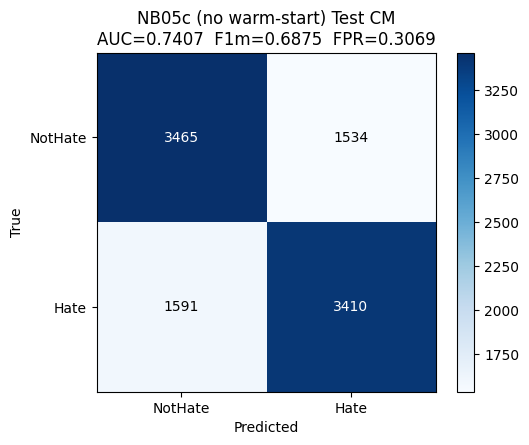

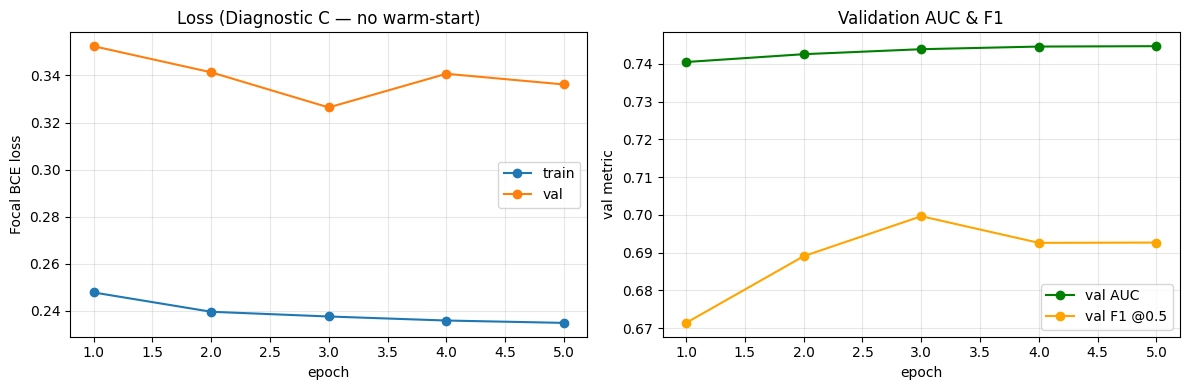

In [8]:
del model
gc.collect(); torch.cuda.empty_cache()

base = AutoModel.from_pretrained(HPARAMS['base_model'])
best_encoder = PeftModel.from_pretrained(base, str(BEST_DIR), is_trainable=False)
head_ckpt = torch.load(BEST_DIR / 'head.pt', map_location='cpu', weights_only=False)
best_head = nn.Linear(base.config.hidden_size, 1)
best_head.load_state_dict(head_ckpt['head'])
print(f'reloaded best (epoch {head_ckpt["epoch"]}, val_auc={head_ckpt["val_auc"]:.4f})')

class _T1Eval(nn.Module):
    def __init__(self, enc, head):
        super().__init__()
        self.encoder = enc; self.head = head
    def forward(self, ids, mask):
        out = self.encoder(input_ids=ids, attention_mask=mask)
        return self.head(out.last_hidden_state[:, 0])

best_model = _T1Eval(best_encoder, best_head).to(device).eval()

all_probs, all_true = [], []
with torch.no_grad(), torch.amp.autocast('cuda', dtype=torch.float16):
    for batch in test_loader:
        ids  = batch['input_ids'].to(device, non_blocking=True)
        mask = batch['attention_mask'].to(device, non_blocking=True)
        y    = batch['label'].cpu().numpy()
        logits = best_model(ids, mask)
        probs = torch.sigmoid(logits.view(-1).float()).cpu().numpy()
        all_probs.append(probs); all_true.append(y)
all_probs = np.concatenate(all_probs); all_true = np.concatenate(all_true)
print(f'test probs: shape={all_probs.shape}, mean={all_probs.mean():.4f}, hate-rate(true)={all_true.mean():.4f}')

test_pred = (all_probs >= HPARAMS['threshold']).astype(int)
auc  = roc_auc_score(all_true, all_probs)
f1m  = f1_score(all_true, test_pred, average='macro')
precm = precision_score(all_true, test_pred, average='macro', zero_division=0)
recm  = recall_score(all_true, test_pred, average='macro', zero_division=0)
cm = confusion_matrix(all_true, test_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()
fpr = fp / max(fp + tn, 1)

print(f'\nTEST @ threshold={HPARAMS["threshold"]} (balanced 50/50 test set):')
print(f'  AUC-ROC       : {auc:.4f}')
print(f'  F1   (macro)  : {f1m:.4f}')
print(f'  Precision (M) : {precm:.4f}')
print(f'  Recall    (M) : {recm:.4f}')
print(f'  Confusion     : TN={tn}, FP={fp}, FN={fn}, TP={tp}')
print(f'  FALSE POSITIVE RATE: {fpr:.4f}')

fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['NotHate', 'Hate']); ax.set_yticklabels(['NotHate', 'Hate'])
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'NB05c (no warm-start) Test CM\nAUC={auc:.4f}  F1m={f1m:.4f}  FPR={fpr:.4f}')
thresh = cm.max() / 2.0
for i in range(2):
    for j in range(2):
        ax.text(j, i, int(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > thresh else 'black')
plt.colorbar(im, ax=ax); plt.tight_layout()
plt.savefig(OUT_DIR / 'nb05_fresh_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.plot(history['epoch'], history['train_loss'], '-o', label='train')
a1.plot(history['epoch'], history['val_loss'], '-o', label='val')
a1.set_xlabel('epoch'); a1.set_ylabel('Focal BCE loss')
a1.set_title('Loss (Diagnostic C — no warm-start)'); a1.legend(); a1.grid(alpha=0.3)
a2.plot(history['epoch'], history['val_auc'], '-o', color='green', label='val AUC')
a2.plot(history['epoch'], history['val_f1'], '-o', color='orange', label='val F1 @0.5')
a2.set_xlabel('epoch'); a2.set_ylabel('val metric')
a2.set_title('Validation AUC & F1'); a2.legend(); a2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'nb05_fresh_training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

In [9]:
prior_hate = HPARAMS['prior_hate']
prior_nothate = HPARAMS['prior_nothate']

def recalibrate(p, ph=prior_hate, pn=prior_nothate):
    """Bayes shift from 50/50 balanced posterior to deployment prior P(hate)=ph.
    p_recal = (p * ph) / (p * ph + (1-p) * pn)"""
    num = p * ph
    den = num + (1 - p) * pn
    return num / np.maximum(den, 1e-12)

val_probs_list, val_true_list = [], []
with torch.no_grad(), torch.amp.autocast('cuda', dtype=torch.float16):
    for batch in val_loader:
        ids  = batch['input_ids'].to(device, non_blocking=True)
        mask = batch['attention_mask'].to(device, non_blocking=True)
        logits = best_model(ids, mask)
        val_probs_list.append(torch.sigmoid(logits.view(-1).float()).cpu().numpy())
        val_true_list.append(batch['label'].cpu().numpy())
val_probs_arr = np.concatenate(val_probs_list)
val_true_arr = np.concatenate(val_true_list)

test_probs_recal = recalibrate(all_probs)
val_probs_recal = recalibrate(val_probs_arr)

best_thr, best_thr_f1 = 0.5, -1.0
for t in np.linspace(0.01, 0.99, 99):
    p = (val_probs_recal >= t).astype(int)
    fv = f1_score(val_true_arr, p)
    if fv > best_thr_f1:
        best_thr_f1 = fv
        best_thr = float(t)
print(f'F1-optimised threshold on RECALIBRATED VAL: {best_thr:.3f}  (val F1={best_thr_f1:.4f})')
print(f'  recalibrated val prob range: [{val_probs_recal.min():.4f}, {val_probs_recal.max():.4f}], mean={val_probs_recal.mean():.4f}')
print(f'  recalibrated test prob range: [{test_probs_recal.min():.4f}, {test_probs_recal.max():.4f}], mean={test_probs_recal.mean():.4f}')

def metrics_at(true_labels, probs, thr):
    pred = (probs >= thr).astype(int)
    auc_  = roc_auc_score(true_labels, probs)
    f1m_  = f1_score(true_labels, pred, average='macro')
    pm_   = precision_score(true_labels, pred, average='macro', zero_division=0)
    rm_   = recall_score(true_labels, pred, average='macro', zero_division=0)
    cm_   = confusion_matrix(true_labels, pred, labels=[0, 1])
    tn, fp, fn, tp = cm_.ravel()
    fpr_  = fp / max(fp + tn, 1)
    return dict(AUC=auc_, F1m=f1m_, Pm=pm_, Rm=rm_, FPR=fpr_,
                TN=int(tn), FP=int(fp), FN=int(fn), TP=int(tp))

m_bal_05 = metrics_at(all_true, all_probs, 0.5)
m_rec_opt = metrics_at(all_true, test_probs_recal, best_thr)

print('\n=== SIDE-BY-SIDE METRICS ===')
print(f'  balanced   (50/50 test, threshold = 0.5)')
print(f'  recalibrated (P(hate)={prior_hate}, threshold = {best_thr:.3f}, F1-opt on recal val)')
print(f'  NOTE: AUC is invariant to monotone recalibration -> same value in both columns.\n')
print(f'  {"metric":<14}  {"balanced (50/50, thr=0.5)":<28}  {"recalibrated (~22% hate, thr=F1-opt)":<40}')
for key, name in [('AUC', 'AUC-ROC'), ('F1m', 'F1 (macro)'),
                  ('Pm', 'Precision (M)'), ('Rm', 'Recall (M)'), ('FPR', 'FPR')]:
    print(f'  {name:<14}  {m_bal_05[key]:<28.4f}  {m_rec_opt[key]:<40.4f}')
print(f'  CM balanced     TN={m_bal_05["TN"]:5} FP={m_bal_05["FP"]:5} FN={m_bal_05["FN"]:5} TP={m_bal_05["TP"]:5}')
print(f'  CM recalibrated TN={m_rec_opt["TN"]:5} FP={m_rec_opt["FP"]:5} FN={m_rec_opt["FN"]:5} TP={m_rec_opt["TP"]:5}')

metrics_summary = {
    'run_label': HPARAMS['run_label'],
    'description': 'Diagnostic C: no NB04 warm-start. Fresh cardiffnlp base + fresh LoRA, pos_weight restored.',
    'best_epoch': int(head_ckpt['epoch']),
    'best_val_auc': float(head_ckpt['val_auc']),
    'pos_weight_used': pos_weight_value,
    'thresholds': {
        'balanced_headline': 0.5,
        'recal_f1_optimised_on_recal_val': best_thr,
    },
    'priors_for_recalibration': {'hate': prior_hate, 'nothate': prior_nothate},
    'balanced_test_thr_0.5':      {k: float(v) if not isinstance(v, int) else v for k, v in m_bal_05.items()},
    'recalibrated_test_thr_opt':  {k: float(v) if not isinstance(v, int) else v for k, v in m_rec_opt.items()},
}
print('\nmetrics_summary keys:', list(metrics_summary.keys()))

F1-optimised threshold on RECALIBRATED VAL: 0.220  (val F1=0.7156)
  recalibrated val prob range: [0.0648, 0.4580], mean=0.2610
  recalibrated test prob range: [0.0680, 0.4695], mean=0.2621

=== SIDE-BY-SIDE METRICS ===
  balanced   (50/50 test, threshold = 0.5)
  recalibrated (P(hate)=0.2468, threshold = 0.220, F1-opt on recal val)
  NOTE: AUC is invariant to monotone recalibration -> same value in both columns.

  metric          balanced (50/50, thr=0.5)     recalibrated (~22% hate, thr=F1-opt)    
  AUC-ROC         0.7407                        0.7407                                  
  F1 (macro)      0.6875                        0.6810                                  
  Precision (M)   0.6875                        0.6873                                  
  Recall (M)      0.6875                        0.6829                                  
  FPR             0.3069                        0.3941                                  
  CM balanced     TN= 3465 FP= 1534 FN= 1591 TP=

In [10]:
# Final save to models/roberta_mvp1_fresh/ (separate from roberta_mvp1/ and roberta_mvp1_iter1/).
if MODEL_DIR.exists() and any(MODEL_DIR.iterdir()):
    for p in list(MODEL_DIR.iterdir()):
        if p.is_file():
            p.unlink()
        elif p.is_dir():
            shutil.rmtree(p)

for src in BEST_DIR.iterdir():
    dst = MODEL_DIR / src.name
    if src.is_dir():
        shutil.copytree(src, dst)
    else:
        shutil.copy2(src, dst)

with open(MODEL_DIR / 'hparams.json', 'w') as f:
    json.dump(HPARAMS, f, indent=2)
with open(MODEL_DIR / 'training_history.json', 'w') as f:
    json.dump(history, f, indent=2)
with open(MODEL_DIR / 'metrics.json', 'w') as f:
    json.dump(metrics_summary, f, indent=2)

print('Saved Diagnostic-C model to', MODEL_DIR)
for p in sorted(MODEL_DIR.iterdir()):
    if p.is_file():
        sz = p.stat().st_size
        unit = 'KB' if sz < 1024**2 else 'MB'
        scale = 1024 if unit == 'KB' else 1024**2
        print(f'  {p.name:>40s}  {sz/scale:>8.2f} {unit}')

# Comparison across the three NB05 runs to date
print('\n=== NB05 RUN COMPARISON ===')
print(f'{"Run":<6} {"Encoder init":<24} {"pos_weight":<11} {"Epochs run":<10} {"Best val AUC":<14} {"Test AUC":<10} {"Test F1m":<10} {"Test FPR":<10}')
print('-' * 105)
print(f'{"Run 1":<6} {"warm-start (NB04)":<24} {"3.5739":<11} {"5":<10} {"0.7457 (ep4)":<14} {"0.7398":<10} {"0.6885":<10} {"0.3071":<10}')
print(f'{"Run 2":<6} {"warm-start (NB04)":<24} {"none":<11} {"1 (halted)":<10} {"0.7424 (ep1)":<14} {"n/a":<10} {"n/a":<10} {"n/a":<10}')
this_test_auc = m_bal_05['AUC']
this_test_f1m = m_bal_05['F1m']
this_test_fpr = m_bal_05['FPR']
this_best_val_auc = float(head_ckpt['val_auc'])
this_best_epoch = int(head_ckpt['epoch'])
print(f'{"Run C":<6} {"FRESH (no warm-start)":<24} {f"{pos_weight_value:.4f}":<11} {str(len(history["epoch"])):<10} '
      f'{f"{this_best_val_auc:.4f} (ep{this_best_epoch})":<14} {f"{this_test_auc:.4f}":<10} '
      f'{f"{this_test_f1m:.4f}":<10} {f"{this_test_fpr:.4f}":<10}')

delta_auc_vs_run1 = this_test_auc - 0.7398
delta_f1_vs_run1 = this_test_f1m - 0.6885
delta_fpr_vs_run1 = this_test_fpr - 0.3071
print(f'\nΔ vs Run 1 (warm-start baseline):')
print(f'  test AUC : {delta_auc_vs_run1:+.4f}')
print(f'  test F1m : {delta_f1_vs_run1:+.4f}')
print(f'  test FPR : {delta_fpr_vs_run1:+.4f}')

if abs(delta_auc_vs_run1) < 0.02:
    verdict = 'NEUTRAL: warm-start has no meaningful effect on AUC (within ±0.02 of Run 1).'
    verdict_detail = 'Plateau cause is downstream of both H1 (loss) and H2 (warm-start). Likely H3 (LoRA capacity / LR schedule).'
elif delta_auc_vs_run1 >= 0.02:
    verdict = 'POSITIVE: removing warm-start HELPS — the NB04 pretext task is hurting MMHS150K T1 fine-tune.'
    verdict_detail = 'Revisit NB04 design (or skip warm-start entirely for MVP 1).'
else:
    verdict = 'NEGATIVE: removing warm-start HURTS — NB04 was genuinely helping despite the plateau.'
    verdict_detail = 'Plateau cause is structural (LoRA capacity / LR / data). Keep warm-start; investigate H3 / H4.'
print(f'\nVERDICT: {verdict}')
print(f'         {verdict_detail}')

print(f'\nNB 05c / Diagnostic C complete. Test AUC = {this_test_auc:.4f}.')

Saved Diagnostic-C model to /teamspace/studios/this_studio/HateFusion/models/roberta_mvp1_fresh
                                 README.md      5.08 KB
                       adapter_config.json      1.02 KB
                 adapter_model.safetensors      2.26 MB
                                   head.pt      4.83 KB
                              hparams.json      0.38 KB
                              metrics.json      0.91 KB
                     training_history.json      0.60 KB

=== NB05 RUN COMPARISON ===
Run    Encoder init             pos_weight  Epochs run Best val AUC   Test AUC   Test F1m   Test FPR  
---------------------------------------------------------------------------------------------------------
Run 1  warm-start (NB04)        3.5739      5          0.7457 (ep4)   0.7398     0.6885     0.3071    
Run 2  warm-start (NB04)        none        1 (halted) 0.7424 (ep1)   n/a        n/a        n/a       
Run C  FRESH (no warm-start)    3.5739      5          0.7447 (ep5) 